> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

# 0. Setup and Dependencies

In [37]:
%pip install matplotlib seaborn numpy pandas scipy scikit-learn tensorflow yfinance fredapi vaderSentiment google-news-api dateparser --quiet
import yfinance as yf
from fredapi import Fred
import seaborn as sns
import numpy as np
import pandas as pd
import time, requests
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pointbiserialr

---
# 1. Fetching Stock Data

In [38]:
# ── Config ──────────────────────────────────────────────────────────────────
TICKER     = 'TSLA'          # Change to any yfinance-supported ticker
START_DATE = '2016-01-01'
END_DATE   = '2025-12-31'

stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
print(f'Downloaded {len(stock_data)} rows for {TICKER}')
stock_data.tail()


/tmp/ipykernel_72739/187181836.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Downloaded 2513 rows for TSLA


,Close,High,Low,Open,Volume
Date,,,,,
2025-12-23,485.559998,491.970001,482.839996,489.399994,58223600
2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700
2025-12-29,459.640015,469.399994,459.000000,469.000000,66263000
2025-12-30,454.429993,463.119995,453.829987,461.089996,59238500


---
# 2. Generate All Candidate Features

### 2.0 Configuration

In [39]:
import os

# Set keys as environment variables (recommended) or paste them directly here.
# FRED key  : https://fred.stlouisfed.org/docs/api/api_key.html  (free)
# AV key    : https://www.alphavantage.co/support/#api-key        (free, 25 req/day)
FRED_API_KEY          = os.environ.get('FRED_API_KEY',   '5e48206e559ddc72e7679880d1a2534f')
ALPHA_VANTAGE_API_KEY = os.environ.get('ALPHA_VANTAGE_KEY', '29LQCTSDLAULW91P.')
# STOCK_DATA_API_KEY    = os.environ.get('STOCK_DATA_KEY', 'KeECt6siKwT3PBSwvwnjI8caKTpluzF51tE3YXh1')
# Pull macro data earlier so rolling windows are warm at TRAIN_START
MACRO_START = '2015-06-01'


### 2.1 Technical Features

In [5]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Moving averages & volatility ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']        = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']        = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

# RSI-14
df['RSI_14'] = 100 - 100 / (
    1 + df['Close'].diff().clip(lower=0).rolling(14).mean()
      / df['Close'].diff().clip(upper=0).abs().rolling(14).mean()
)

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# Bollinger Bands
sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

# ATR-14
high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

# OBV
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']  = df['Close'].pct_change()
df['return_5d']  = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']   = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Cyclical time features ---
# np.where avoids pandas ExtensionArray issues with is_leap_year
year_days = np.where(df.index.is_leap_year, 366, 365)
df['sin_year']    = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year']    = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# isocalendar().week returns an ExtensionArray — cast to float before numpy ops
week_num = df.index.isocalendar().week.values.astype(float)
df['sin_week'] = np.sin(2 * np.pi * (week_num - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (week_num - 1) / 52)

df['sin_month']   = np.sin(2 * np.pi * (df.index.month   - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df.index.month   - 1) / 12)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# Days since start - monotonic time feature (critical for trending stocks)
df['days_since_start'] = np.arange(len(df))

# Target: next-day close
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()

print(f'Technical features shape: {df.shape}')


Technical features shape: (2462, 42)


### 2.2 Macro Feature (Pulled from FRED)
| Series | FRED Code | Why It Helps |
|---|---|---|
| VIX | `VIXCLS` | Market fear gauge — spikes before and during crashes |
| Yield curve (10Y-2Y) | `T10Y2Y` | Inversion reliably precedes recessions |
| Fed Funds Rate | `FEDFUNDS` | Rate hike cycles crush tech/growth stocks |
| Credit spread (BAA-AAA) | computed | Widens before financial stress events |
| Unemployment | `UNRATE` | Lagging but useful for recession regime detection |

In [6]:
import pandas as pd
from fredapi import Fred


def fetch_macro_data(
    fred_api_key,
    start_date="2015-01-01",
    end_date="2025-12-31",
):
    """
    Fetch macroeconomic indicators from FRED and return a clean
    daily-frequency dataframe.

    Features:
    ---------
    - Pulls major macro indicators from FRED
    - Converts everything to daily frequency
    - Forward-fills monthly/weekly series
    - Adds derived recession/stress indicators
    - Handles missing series safely

    Parameters
    ----------
    fred_api_key : str
        FRED API key

    start_date : str
        Start date (YYYY-MM-DD)

    end_date : str
        End date (YYYY-MM-DD)

    Returns
    -------
    pd.DataFrame
        Daily macroeconomic feature dataframe
    """

    # ------------------------------------------------------------------
    # Validate API key
    # ------------------------------------------------------------------
    if not fred_api_key or fred_api_key == "YOUR_FRED_KEY_HERE":
        print("⚠️ No valid FRED API key provided.")
        print("Get a free key:")
        print("https://fred.stlouisfed.org/docs/api/api_key.html")
        return pd.DataFrame()

    fred = Fred(api_key=fred_api_key)

    # ------------------------------------------------------------------
    # FRED series mapping
    # ------------------------------------------------------------------
    SERIES = {
        "vix": "VIXCLS",
        "yield_curve": "T10Y2Y",
        "fed_funds": "FEDFUNDS",
        "baa_rate": "BAA",
        "aaa_rate": "AAA",
        "unemployment": "UNRATE",
    }

    # ------------------------------------------------------------------
    # Create master daily index
    # ------------------------------------------------------------------
    daily_index = pd.date_range(start=start_date, end=end_date, freq="D")

    frames = {}

    print("Fetching FRED macro data...\n")

    # ------------------------------------------------------------------
    # Download each series
    # ------------------------------------------------------------------
    for feature_name, fred_code in SERIES.items():

        try:
            series = fred.get_series(
                fred_code,
                observation_start=start_date,
                observation_end=end_date,
            )

            # Ensure datetime index
            series.index = pd.to_datetime(series.index)

            # Sort index
            series = series.sort_index()

            # Remove duplicates
            series = series[~series.index.duplicated(keep="first")]

            # Reindex to daily frequency
            series = series.reindex(daily_index)

            # Forward fill slower-moving data
            series = series.ffill()

            # Rename series
            series.name = feature_name

            frames[feature_name] = series

            print(
                f"✓ {feature_name:<15} "
                f"{fred_code:<10} "
                f"{series.notna().sum():>6} observations"
            )

        except Exception as e:
            print(f"✗ Failed: {feature_name} ({fred_code}) -> {e}")

    # ------------------------------------------------------------------
    # Combine all features
    # ------------------------------------------------------------------
    macro_df = pd.concat(frames.values(), axis=1)

    # ------------------------------------------------------------------
    # Derived Features
    # ------------------------------------------------------------------

    # Credit spread
    if {"baa_rate", "aaa_rate"}.issubset(macro_df.columns):
        macro_df["credit_spread"] = (
            macro_df["baa_rate"] - macro_df["aaa_rate"]
        )

    # Yield curve inversion
    if "yield_curve" in macro_df.columns:
        macro_df["yield_inverted"] = (
            macro_df["yield_curve"] < 0
        ).astype(int)

    # ------------------------------------------------------------------
    # VIX Features
    # ------------------------------------------------------------------
    if "vix" in macro_df.columns:

        # 252 trading days ≈ 1 year
        rolling_window = 252

        vix_roll_mean = macro_df["vix"].rolling(
            rolling_window,
            min_periods=30
        ).mean()

        # Spike indicator
        macro_df["vix_spike"] = (
            macro_df["vix"] > (vix_roll_mean * 1.5)
        ).astype(int)

        # Percentile rank
        macro_df["vix_percentile"] = (
            macro_df["vix"]
            .rolling(rolling_window, min_periods=30)
            .rank(pct=True)
        )

    # ------------------------------------------------------------------
    # Unemployment Trend
    # ------------------------------------------------------------------
    if "unemployment" in macro_df.columns:

        macro_df["unemployment_change_3m"] = (
            macro_df["unemployment"].diff(90)
        )

    # ------------------------------------------------------------------
    # Final Cleanup
    # ------------------------------------------------------------------

    # Remove leading NaNs from rolling features
    macro_df = macro_df.ffill()

    # Optional:
    # macro_df = macro_df.dropna()

    print("\nDone.")
    print(f"Macro DataFrame shape: {macro_df.shape}")

    return macro_df

macro_df = fetch_macro_data(FRED_API_KEY, MACRO_START, END_DATE)
if not macro_df.empty:
    macro_df.tail()

Fetching FRED macro data...

✓ vix             VIXCLS       3867 observations
✓ yield_curve     T10Y2Y       3867 observations
✓ fed_funds       FEDFUNDS     3867 observations
✓ baa_rate        BAA          3867 observations
✓ aaa_rate        AAA          3867 observations
✓ unemployment    UNRATE       3867 observations

Done.
Macro DataFrame shape: (3867, 11)


### 2.3 Sentiment Data (from Alpha Vantage News)

In [7]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
import pandas as pd
import numpy as np
import requests
import time

# Source credibility tiers
SOURCE_WEIGHTS = {
    'reuters.com': 3.0, 'bloomberg.com': 3.0,
    'wsj.com': 2.5,     'ft.com': 2.5,
    'apnews.com': 2.5,  'cnbc.com': 2.0,
    'marketwatch.com': 1.8, 'barrons.com': 2.0,
    'fool.com': 1.2,    'seekingalpha.com': 1.2,
}
DEFAULT_WEIGHT = 1.0


def _normalize_sentiment_score(item):
    score = item.get('overall_sentiment_score')
    if score is not None:
        try:
            return float(score)
        except Exception:
            pass
    label = item.get('overall_sentiment_label') or item.get('overall_sentiment')
    if isinstance(label, str):
        label = label.strip().lower()
        if label == 'positive':  return  1.0
        if label == 'negative':  return -1.0
        if label == 'neutral':   return  0.0
    return None


def _ticker_score(item, ticker):
    for ts in item.get('ticker_sentiment', []):
        if ts.get('ticker', '').upper() == ticker.upper():
            try:
                score = float(ts['ticker_sentiment_score'])
                relevance = float(ts.get('relevance_score', 1.0))
                return score, relevance
            except (KeyError, ValueError, TypeError):
                pass
    return None, 0.0


def fetch_alpha_vantage_news_sentiment(ticker, start_date=None, end_date=None):
    api_key = ALPHA_VANTAGE_API_KEY
    if not api_key or api_key == 'YOUR_KEY_HERE':
        print('No Alpha Vantage API key -- returning empty sentiment frame.')
        return pd.DataFrame()

    start = pd.to_datetime(start_date)
    end   = pd.to_datetime(end_date)
    if start > end:
        return pd.DataFrame()

    records = []
    chunk_start = start

    while chunk_start <= end:
        chunk_end  = min(chunk_start + relativedelta(years=1) - pd.Timedelta(seconds=1), end)
        time_from  = chunk_start.strftime('%Y%m%dT%H%M')
        time_to    = chunk_end.strftime('%Y%m%dT%H%M')

        params = {
            'function': 'NEWS_SENTIMENT',
            'tickers':  ticker,
            'time_from': time_from,
            'time_to':   time_to,
            'limit':     1000,
            'apikey':    api_key,
        }

        print(f'Fetching {ticker} sentiment: {time_from} -> {time_to}')
        try:
            response = requests.get(
                'https://www.alphavantage.co/query',
                params=params, timeout=30
            )
            response.raise_for_status()
            data = response.json()
        except Exception as e:
            print(f'  Request failed: {e}')
            break

        feed = data.get('feed') or data.get('items') or []
        if isinstance(feed, dict):
            feed = [feed]

        for item in feed:
            published = (item.get('time_published')
                         or item.get('published_at')
                         or item.get('published'))
            if not published:
                continue
            try:
                pub_date = pd.to_datetime(published, utc=True).tz_convert(None).normalize()
            except Exception:
                continue

            overall_score = _normalize_sentiment_score(item)
            ticker_score, relevance = _ticker_score(item, ticker)
            final_score = ticker_score if ticker_score is not None else overall_score
            if final_score is None:
                continue

            source_domain = (item.get('source_domain') or '').lower().strip()
            weight = SOURCE_WEIGHTS.get(source_domain, DEFAULT_WEIGHT)

            records.append({
                'date':          pub_date,
                'score':         final_score,
                'source_weight': weight,
                'relevance':     relevance,
            })

        chunk_start = chunk_end + pd.Timedelta(seconds=1)
        time.sleep(1)

    if not records:
        print('No sentiment records found.')
        return pd.DataFrame()

    raw = pd.DataFrame(records)

    def daily_agg(g):
        scores  = g['score'].values
        weights = g['source_weight'].values
        n       = len(scores)
        return pd.Series({
            'sentiment_score':      scores.mean(),
            'sentiment_weighted':   np.average(scores, weights=weights),
            'sentiment_dispersion': scores.std() if n > 1 else 0.0,
            'article_count':        n,
            'sentiment_volume_wt':   scores.mean() * np.log1p(n),
        })

    daily = raw.groupby('date').apply(daily_agg)
    daily.index.name = 'Date'

    print(f'{len(daily)} daily sentiment rows | '
          f'avg score: {daily["sentiment_score"].mean():+.3f} | '
          f'avg articles/day: {daily["article_count"].mean():.1f}')
    return daily


def build_sentiment_momentum(df, window=5):
    if 'sentiment_score' not in df.columns:
        return df
    rolling_mean = df['sentiment_score'].ffill().rolling(window, min_periods=1).mean()
    df['sentiment_momentum'] = df['sentiment_score'].ffill() - rolling_mean
    return df


sentiment_df = fetch_alpha_vantage_news_sentiment(TICKER, START_DATE, END_DATE)

if sentiment_df.empty:
    print('No Alpha Vantage sentiment data fetched.')



Fetching TSLA sentiment: 20160101T0000 -> 20161231T2359
Fetching TSLA sentiment: 20170101T0000 -> 20171231T2359
Fetching TSLA sentiment: 20180101T0000 -> 20181231T2359
Fetching TSLA sentiment: 20190101T0000 -> 20191231T2359
Fetching TSLA sentiment: 20200101T0000 -> 20201231T2359
Fetching TSLA sentiment: 20210101T0000 -> 20211231T2359
Fetching TSLA sentiment: 20220101T0000 -> 20221231T2359
Fetching TSLA sentiment: 20230101T0000 -> 20231231T2359
Fetching TSLA sentiment: 20240101T0000 -> 20241231T2359
Fetching TSLA sentiment: 20250101T0000 -> 20251231T0000
1578 daily sentiment rows | avg score: +0.092 | avg articles/day: 2.7


/tmp/ipykernel_72739/1160634967.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = raw.groupby('date').apply(daily_agg)


In [8]:
sentiment_df.head()

,sentiment_score,sentiment_weighted,sentiment_dispersion,article_count,sentiment_volume_wt
Date,,,,,
2016-01-01,0.002876,0.002876,0.131347,2.0,0.003160
2016-01-04,0.144706,0.144706,0.000000,1.0,0.100303
2016-01-11,0.143494,0.143494,0.000000,1.0,0.099462
2016-01-14,0.154519,0.154519,0.000000,1.0,0.107104
2016-01-15,0.128474,0.128474,0.000000,1.0,0.089051


In [9]:
os.makedirs('data', exist_ok=True)   # safe on Colab, Kaggle, VS Code, local

macro_df.to_csv('data/macro_data.csv')
sentiment_df.to_csv('data/sentiment.csv')
df.to_csv(f'data/stock_data_{TICKER}.csv')
print('\u2705 Raw data saved to data/')


✅ Raw data saved to data/


In [10]:
os.makedirs('data', exist_ok=True)   # safe on Colab, Kaggle, VS Code, local

stock_data.to_csv(f'data/stock_data_{TICKER}.csv')
macro_df.to_csv(f'data/macro_data_{TICKER}.csv')
sentiment_df.to_csv(f'data/sentiment_{TICKER}.csv')
df.to_csv(f'data/stock_data_{TICKER}.csv')
print('✔️ Raw data saved to data')

✔️ Raw data saved to data


## Data Pre-Processing

In [11]:
df = pd.read_csv(f'data/stock_data_{TICKER}.csv', index_col=0, parse_dates=True).copy()

### Merge and Clean Data

In [12]:
# Ensure all indices are timezone-naive datetime

def _to_utc_naive(idx):
    idx = pd.to_datetime(idx)
    return idx.tz_localize(None) if idx.tzinfo is not None else idx


df.index           = _to_utc_naive(df.index)
macro_df.index     = _to_utc_naive(macro_df.index)
sentiment_df.index = _to_utc_naive(sentiment_df.index)


def _resample_to_daily(src, target_index):
    if src.empty:
        return pd.DataFrame(index=target_index)
    return (
        src.select_dtypes(include=[np.number])
           .reindex(target_index, method='ffill')
    )


macro_daily     = _resample_to_daily(macro_df,     df.index)
sentiment_daily = _resample_to_daily(sentiment_df, df.index)


# Safeguard: reload df from CSV if missing stock columns
if 'Close' not in df.columns or 'High' not in df.columns:
    print("WARNING: df missing stock columns, reloading from CSV...")
    df = pd.read_csv(f'data/stock_data_{TICKER}.csv', index_col=0, parse_dates=True)
    print(f'Reloaded df shape: {df.shape}')


print(f'Original df shape: {df.shape}')
print(f'Original df columns (first 10): {df.columns.tolist()[:10]}')

df_merged = df.copy()
print(f'df_merged copy shape: {df_merged.shape}')

macro_overlap = [c for c in macro_daily.columns if c in df_merged.columns]
if macro_overlap:
    df_merged = df_merged.drop(columns=macro_overlap)
df_merged = df_merged.join(macro_daily, how='left')

sentiment_overlap = [c for c in sentiment_daily.columns if c in df_merged.columns]
if sentiment_overlap:
    df_merged = df_merged.drop(columns=sentiment_overlap)
df_merged = df_merged.join(sentiment_daily, how='left')

print(f'df_merged shape after join: {df_merged.shape}')

# Forward fill macro columns only (they update at lower frequency)
macro_cols = [c for c in df_merged.columns if c in macro_df.columns]
for col in macro_cols:
    df_merged[col] = df_merged[col].ffill()
    df_merged[f'{col}_available'] = df_merged[col].notna().astype(float)

# Fill sentiment columns (sparse, mostly NaN)
sentiment_cols_new = ['sentiment_score', 'sentiment_weighted', 'article_count',
                       'sentiment_dispersion', 'sentiment_volume_wt']
for col in sentiment_cols_new:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0)

# Only drop rows where target is missing (not entire row)
df = df_merged.dropna(subset=['Close'])
print(f'Merged shape after targeted dropna: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()[:10]}...')

# Recreate Close_nxt target column
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna(subset=['Close_nxt'])  # Only drop last row where target is NaN
print(f'After adding Close_nxt: {df.shape}')

# Build sentiment momentum feature (captures narrative shifts)
df = build_sentiment_momentum(df, window=5)
print(f'After sentiment_momentum: {df.shape}')



Original df shape: (2462, 42)
Original df columns (first 10): ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']
df_merged copy shape: (2462, 42)
df_merged shape after join: (2462, 58)
Merged shape after targeted dropna: (2462, 69)
Columns (69): ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']...
After adding Close_nxt: (2461, 69)
After sentiment_momentum: (2461, 70)


In [13]:
df.head()

,Close,High,Low,Open,Volume,SMA_5,EMA_5,Volatility_5,SMA_10,EMA_10,...,fed_funds_available,baa_rate_available,aaa_rate_available,unemployment_available,credit_spread_available,yield_inverted_available,vix_spike_available,vix_percentile_available,unemployment_change_3m_available,sentiment_momentum
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-16,14.795333,14.838667,14.468000,14.533333,52750500,14.241333,14.334582,0.019262,13.876600,13.877499,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-17,15.092000,15.233333,14.666667,14.764667,56743500,14.524000,14.587055,0.009993,14.080867,14.098324,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-18,15.516000,15.632000,15.204000,15.273333,70677000,14.860533,14.896703,0.009171,14.292200,14.356090,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-21,15.888000,15.992000,15.666667,15.689333,79617000,15.169466,15.227135,0.005442,14.512400,14.634624,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-22,15.616000,15.932667,15.504000,15.814000,64740000,15.381466,15.356757,0.018088,14.723333,14.813059,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [14]:
os.makedirs('data', exist_ok=True)
df.to_csv(f'data/stock_data_{TICKER}_final.csv')
print(f'\u2705 Merged dataset saved \u2192 data/stock_data_{TICKER}_final.csv')


✅ Merged dataset saved → data/stock_data_TSLA_final.csv


---
# 3. Feature Selection
**Computing MI Score**

Why not just use Pearson correlation instead?
- vix_spike is binary (0 or 1) — Pearson can't handle that properly
- sin_week / cos_week are cyclical — Pearson would underestimate their importance

In [40]:
df = pd.read_csv(f'data/stock_data_{TICKER}_final.csv', index_col=0, parse_dates=True)
print(f'Loaded {df.shape[0]} rows \u00d7 {df.shape[1]} columns')
df.head()


Loaded 2461 rows × 70 columns


,Close,High,Low,Open,Volume,SMA_5,EMA_5,Volatility_5,SMA_10,EMA_10,...,fed_funds_available,baa_rate_available,aaa_rate_available,unemployment_available,credit_spread_available,yield_inverted_available,vix_spike_available,vix_percentile_available,unemployment_change_3m_available,sentiment_momentum
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-16,14.795333,14.838667,14.468000,14.533333,52750500,14.241333,14.334582,0.019262,13.876600,13.877499,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-17,15.092000,15.233333,14.666667,14.764667,56743500,14.524000,14.587055,0.009993,14.080867,14.098324,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-18,15.516000,15.632000,15.204000,15.273333,70677000,14.860533,14.896703,0.009171,14.292200,14.356090,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-21,15.888000,15.992000,15.666667,15.689333,79617000,15.169466,15.227135,0.005442,14.512400,14.634624,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2016-03-22,15.616000,15.932667,15.504000,15.814000,64740000,15.381466,15.356757,0.018088,14.723333,14.813059,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [41]:
'''Target and Feature Creation'''
target_col = ['Close_nxt']

# Select only numeric columns (exclude Date, headline, and any other non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in target_col]

After MI pre-filter (MI > 0.05 + protected pairs): 54 features


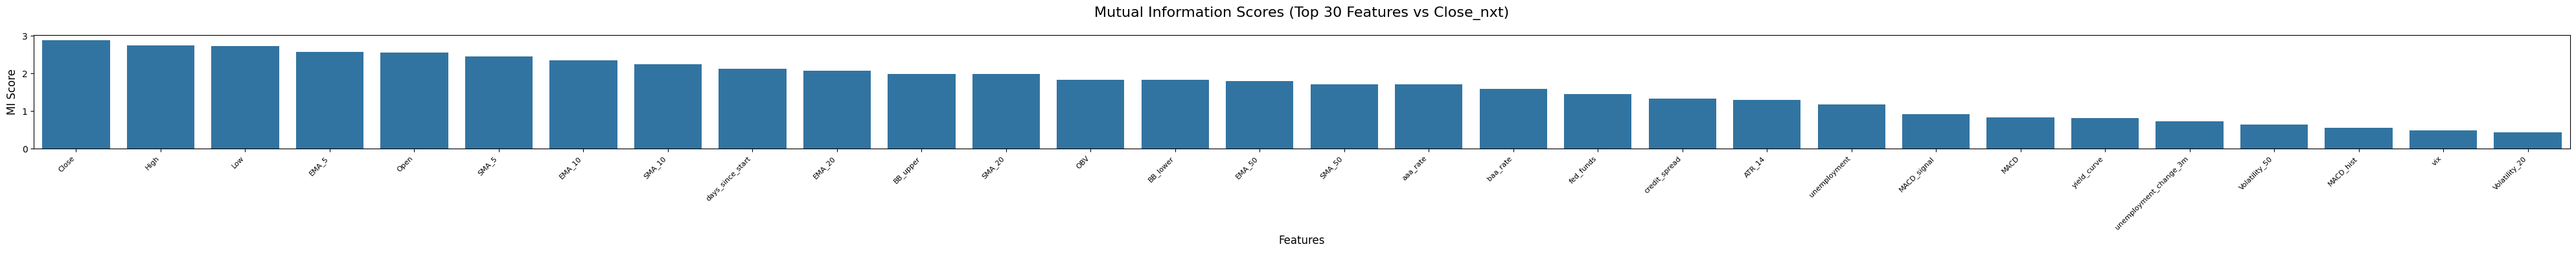


Top 15 Features by Mutual Information:
Close               2.878126
High                2.738625
Low                 2.729247
EMA_5               2.570682
Open                2.559249
SMA_5               2.456111
EMA_10              2.344676
SMA_10              2.238349
days_since_start    2.118789
EMA_20              2.064172
BB_upper            1.989756
SMA_20              1.983409
OBV                 1.838403
BB_lower            1.838299
EMA_50              1.791219
dtype: float64


In [42]:
# -------- MUTUAL INFORMATION PRE-FILTER  -------
# Pearson is inappropriate for binary features (vix_spike, yield_inverted) and loses cyclical info
from sklearn.feature_selection import mutual_info_regression

# Sample for faster computation
np.random.seed(42)
sample_size = min(1000, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)
X_sample = df[feature_cols].iloc[sample_idx].fillna(0).values  # Handle NaN
y_sample = df[target_col].iloc[sample_idx].values.ravel()

# Compute mutual information
mi = mutual_info_regression(X_sample, y_sample, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi, index=feature_cols)

# Keep features with MI > threshold
MI_THRESHOLD = 0.05
keep_mi = mi_series[mi_series > MI_THRESHOLD].index.tolist()

PROTECTED_PAIRS = [('sin_week','cos_week'), ('sin_month','cos_month'), 
                   ('sin_year','cos_year'), ('sin_quarter','cos_quarter')]
protected_cols = {c for pair in PROTECTED_PAIRS for c in pair}

feature_cols = [f for f in feature_cols if f in keep_mi or f in protected_cols]
print(f"After MI pre-filter (MI > {MI_THRESHOLD} + protected pairs): {len(feature_cols)} features")

# Visualize MI scores
plt.figure(figsize=(40, 4))
sns.barplot(x=mi_series.sort_values(ascending=False).index[:30], 
            y=mi_series.sort_values(ascending=False).values[:30])
plt.title("Mutual Information Scores (Top 30 Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("MI Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 15 Features by Mutual Information:")
print(mi_series.sort_values(ascending=False).head(15))

In [43]:
# -------- FEATURE CATEGORY DEFINITION -------
# Divide features into 3 groups: technical, macro, sentiment

TECH_FEATURES = [
    # Moving averages & volatility
    'SMA_5', 'EMA_5', 'Volatility_5',
    'SMA_10', 'EMA_10', 'Volatility_10',
    'SMA_20', 'EMA_20', 'Volatility_20',
    'SMA_50', 'EMA_50', 'Volatility_50',
    # Momentum indicators
    'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist',
    # Bollinger Bands
    'BB_upper', 'BB_lower', 'BB_width',
    # Other indicators
    'ATR_14', 'OBV',
    # Returns
    'log_return', 'return_1d', 'return_5d',
    # Price ratios
    'high_low_ratio', 'close_open_ratio',
    # Cyclical time
    'sin_year', 'cos_year', 'day_of_week',
    'sin_week', 'cos_week',
    'sin_month', 'cos_month',
    'sin_quarter', 'cos_quarter',
    # Trend
    'days_since_start',
]

MACRO_FEATURES = [
    'vix', 'yield_curve', 'fed_funds',
    'baa_rate', 'aaa_rate', 'unemployment',
    'credit_spread', 'yield_inverted',
    'vix_spike', 'vix_percentile',
    'unemployment_change_3m',
    # _available flags
    'vix_available', 'yield_curve_available', 'fed_funds_available',
    'baa_rate_available', 'aaa_rate_available', 'unemployment_available',
    'credit_spread_available', 'yield_inverted_available',
    'vix_spike_available', 'vix_percentile_available',
    'unemployment_change_3m_available',
]

SENTIMENT_FEATURES = [
    'sentiment_score', 'sentiment_weighted',
    'sentiment_dispersion', 'article_count',
    'sentiment_volume_wt', 'sentiment_momentum',
]

# Filter each category to only features that exist in df
tech_features_valid     = [f for f in TECH_FEATURES     if f in df.columns]
macro_features_valid   = [f for f in MACRO_FEATURES   if f in df.columns]
sentiment_features_valid = [f for f in SENTIMENT_FEATURES if f in df.columns]

print(f"Feature categories defined:")
print(f"  Technical : {len(tech_features_valid)} features")
print(f"  Macro     : {len(macro_features_valid)} features")
print(f"  Sentiment : {len(sentiment_features_valid)} features")
print(f"  Total     : {len(tech_features_valid)+len(macro_features_valid)+len(sentiment_features_valid)} features")


Feature categories defined:
  Technical : 36 features
  Macro     : 22 features
  Sentiment : 6 features
  Total     : 64 features


In [ ]:
# -------- LASSO CV VOTING: TECHNICAL FEATURES -------
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

X_tech = df[tech_features_valid].fillna(0).values
y_tech = df[target_col].values.ravel()

tscv = TimeSeriesSplit(n_splits=5)
selection_counts_tech = np.zeros(len(tech_features_valid), dtype=int)

print("Running LASSO CV voting on TECHNICAL features across 5 time-series folds...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tech), 1):
    X_tr, y_tr = X_tech[train_idx], y_tech[train_idx]
    scaler_fold = RobustScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr)
    lasso = LassoCV(cv=3, max_iter=10000, random_state=42, n_alphas=50)
    lasso.fit(X_tr_sc, y_tr.ravel())
    selected = (lasso.coef_ != 0).astype(int)
    selection_counts_tech += selected
    print(f"  Fold {fold}: {selected.sum()} features selected, best alpha={lasso.alpha_:.6f}")

MIN_VOTES = 3
keep_mask_tech = selection_counts_tech >= MIN_VOTES
sel_tech = [tech_features_valid[i] for i, k in enumerate(keep_mask_tech) if k]
print(f"\nTECHNICAL: {len(sel_tech)} features selected: {sel_tech}")


Running LASSO CV voting on TECHNICAL features across 5 time-series folds...
  Fold 1: 19 features selected, best alpha=0.003765
  Fold 2: 11 features selected, best alpha=0.016064
  Fold 3: 6 features selected, best alpha=0.353634
  Fold 4: 16 features selected, best alpha=0.089358
  Fold 5: 12 features selected, best alpha=0.130635

TECHNICAL: 14 features selected: ['EMA_5', 'Volatility_5', 'Volatility_50', 'RSI_14', 'MACD_hist', 'BB_upper', 'BB_lower', 'OBV', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_quarter', 'cos_quarter']


In [45]:
# -------- LASSO CV VOTING: MACRO FEATURES -------
X_macro = df[macro_features_valid].fillna(0).values
y_macro = df[target_col].values.ravel()

tscv = TimeSeriesSplit(n_splits=5)
selection_counts_macro = np.zeros(len(macro_features_valid), dtype=int)

print("Running LASSO CV voting on MACRO features across 5 time-series folds...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_macro), 1):
    X_tr, y_tr = X_macro[train_idx], y_macro[train_idx]
    scaler_fold = RobustScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr)
    lasso = LassoCV(cv=3, max_iter=10000, random_state=42, n_alphas=50)
    lasso.fit(X_tr_sc, y_tr.ravel())
    selected = (lasso.coef_ != 0).astype(int)
    selection_counts_macro += selected
    print(f"  Fold {fold}: {selected.sum()} features selected, best alpha={lasso.alpha_:.6f}")

keep_mask_macro = selection_counts_macro >= MIN_VOTES
sel_macro = [macro_features_valid[i] for i, k in enumerate(keep_mask_macro) if k]
print(f"\nMACRO: {len(sel_macro)} features selected: {sel_macro}")


Running LASSO CV voting on MACRO features across 5 time-series folds...
  Fold 1: 6 features selected, best alpha=0.067016
  Fold 2: 1 features selected, best alpha=0.920276
  Fold 3: 3 features selected, best alpha=12.353247
  Fold 4: 1 features selected, best alpha=52.034090
  Fold 5: 1 features selected, best alpha=68.305402

MACRO: 1 features selected: ['unemployment_change_3m']


In [46]:
# -------- LASSO CV VOTING: SENTIMENT FEATURES -------
X_sent = df[sentiment_features_valid].fillna(0).values
y_sent = df[target_col].values.ravel()

tscv = TimeSeriesSplit(n_splits=5)
selection_counts_sent = np.zeros(len(sentiment_features_valid), dtype=int)

print("Running LASSO CV voting on SENTIMENT features across 5 time-series folds...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sent), 1):
    X_tr, y_tr = X_sent[train_idx], y_sent[train_idx]
    scaler_fold = RobustScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr)
    lasso = LassoCV(cv=3, max_iter=10000, random_state=42, n_alphas=50)
    lasso.fit(X_tr_sc, y_tr.ravel())
    selected = (lasso.coef_ != 0).astype(int)
    selection_counts_sent += selected
    print(f"  Fold {fold}: {selected.sum()} features selected, best alpha={lasso.alpha_:.6f}")

keep_mask_sent = selection_counts_sent >= MIN_VOTES
sel_sent = [sentiment_features_valid[i] for i, k in enumerate(keep_mask_sent) if k]
print(f"\nSENTIMENT: {len(sel_sent)} features selected: {sel_sent}")


Running LASSO CV voting on SENTIMENT features across 5 time-series folds...
  Fold 1: 1 features selected, best alpha=0.177916
  Fold 2: 0 features selected, best alpha=0.298882
  Fold 3: 3 features selected, best alpha=3.563056
  Fold 4: 5 features selected, best alpha=0.086921
  Fold 5: 3 features selected, best alpha=1.969983

SENTIMENT: 3 features selected: ['sentiment_dispersion', 'article_count', 'sentiment_volume_wt']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 11.883648395271848, tolerance: 0.6280914943927058
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 59.63763197982007, tolerance: 0.6280914943927058
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 91.88408452491603, tolerance: 0.6280914943927058
  model = cd_fast.enet_coordinate_descent_gram(


In [47]:
# -------- COMBINE SELECTED FEATURES -------
# Merge all three category selections
selected_features = sel_tech + sel_macro + sel_sent

# Ensure days_since_start is always included (trend anchor)
if 'days_since_start' not in selected_features:
    selected_features.append('days_since_start')

print(f"\n{'='*60}")
print(f"Combined feature selection ({len(selected_features)} features):")
print(f"  Technical : {len(sel_tech)} features")
print(f"  Macro     : {len(sel_macro)} features")
print(f"  Sentiment : {len(sel_sent)} features")
print(f"  All       : {selected_features}")
print(f"{'='*60}")



Combined feature selection (19 features):
  Technical : 14 features
  Macro     : 1 features
  Sentiment : 3 features
  All       : ['EMA_5', 'Volatility_5', 'Volatility_50', 'RSI_14', 'MACD_hist', 'BB_upper', 'BB_lower', 'OBV', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_quarter', 'cos_quarter', 'unemployment_change_3m', 'sentiment_dispersion', 'article_count', 'sentiment_volume_wt', 'days_since_start']


In [ ]:
# -------- NMI FEATURE SIMILARITY FILTER -------
# Normalized Mutual Information to detect and remove redundant features
# Uses permutation test (500 iterations) to ensure significance
# Threshold tau = 0.8 (NMI > 0.8 means highly similar)

NMI_THRESHOLD = 0.8
PERMUTATION_ITERS = 500
P_VALUE_THRESHOLD = 0.05

def entropy(x):
    p = np.histogram(x, bins='auto', density=True)[0]
    p = p[p > 0]
    return -np.sum(p * np.log2(p + 1e-12))

def mutual_info(x, y):
    h_x = entropy(x)
    h_y = entropy(y)
    if h_x == 0 or h_y == 0:
        return 0.0
    xy = np.stack([x, y], axis=1)
    counts = {}
    for row in xy:
        key = tuple(row)
        counts[key] = counts.get(key, 0) + 1
    total = len(xy)
    mi = 0.0
    for (xi, yi), cxy in counts.items():
        px = sum(v for (xj, yj), v in counts.items() if xj == xi) / total
        py = sum(v for (xj, yj), v in counts.items() if yj == yi) / total
        pxy = cxy / total
        if px > 0 and py > 0 and pxy > 0:
            mi += pxy * np.log2(pxy / (px * py) + 1e-12)
    return max(mi, 0.0)

def nmi_between(f1_vals, f2_vals):
    h1 = entropy(f1_vals)
    h2 = entropy(f2_vals)
    if h1 == 0 or h2 == 0:
        return 0.0
    mi = mutual_info(f1_vals, f2_vals)
    return mi / np.sqrt(h1 * h2 + 1e-12)

def permutation_test(f1_vals, f2_vals, n_iters=500):
    real_mi = mutual_info(f1_vals, f2_vals)
    shuffled_mis = []
    f2_shuffled = f2_vals.copy()
    for _ in range(n_iters):
        np.random.shuffle(f2_shuffled)
        shuffled_mis.append(mutual_info(f1_vals, f2_shuffled))
    shuffled_mis = np.array(shuffled_mis)
    p_value = np.mean(shuffled_mis >= real_mi)
    return real_mi, p_value

# Prepare data
X_comb = df[selected_features].fillna(0).values
n_feats = len(selected_features)
feat_arr = X_comb.T  # (n_feats, n_samples)

# Compute NMI matrix
print("Computing NMI matrix...")
nmi_matrix = np.zeros((n_feats, n_feats))
for i in range(n_feats):
    for j in range(i + 1, n_feats):
        nmi_val = nmi_between(feat_arr[i], feat_arr[j])
        nmi_matrix[i, j] = nmi_val
        nmi_matrix[j, i] = nmi_val

print(f"NMI matrix computed for {n_feats} features")

# Permutation test for high-NMI pairs
print(f"Running permutation tests ({PERMUTATION_ITERS} iterations) for pairs with NMI > {NMI_THRESHOLD}...")
redundant_pairs = []
for i in range(n_feats):
    for j in range(i + 1, n_feats):
        if nmi_matrix[i, j] > NMI_THRESHOLD:
            real_mi, p_val = permutation_test(feat_arr[i], feat_arr[j], PERMUTATION_ITERS)
            if p_val <= P_VALUE_THRESHOLD:
                redundant_pairs.append((i, j, nmi_matrix[i, j], p_val))

print(f"Found {len(redundant_pairs)} statistically significant redundant pairs (p <= {P_VALUE_THRESHOLD})")
for (i, j, nmi_val, p) in sorted(redundant_pairs, key=lambda x: -x[2]):
    print(f"  {selected_features[i]} <-> {selected_features[j]}: NMI={nmi_val:.4f}, p={p:.4f}")

# Greedy removal: drop feature with lower MI-to-target
removed_features = []
to_remove = set()

if redundant_pairs:
    from collections import defaultdict
    edges = defaultdict(list)
    for (i, j, nmi_val, p) in redundant_pairs:
        edges[i].append((j, nmi_val))
        edges[j].append((i, nmi_val))

    sorted_pairs = sorted(redundant_pairs, key=lambda x: -x[2])

    for (i, j, nmi_val, p) in sorted_pairs:
        if i in to_remove or j in to_remove:
            continue
        mi_i = mi_series.get(selected_features[i], 0)
        mi_j = mi_series.get(selected_features[j], 0)
        drop_idx = j if mi_i >= mi_j else i
        removed_features.append((selected_features[drop_idx], selected_features[j if drop_idx == i else i], nmi_val))
        to_remove.add(drop_idx)

    final_features = [f for idx, f in enumerate(selected_features) if idx not in to_remove]
else:
    final_features = selected_features[:]

print(f"\nNMI Filter removed {len(removed_features)} features:")
for removed, kept_with, nmi_val in removed_features:
    print(f"  REMOVED: {removed} (NMI with {kept_with} = {nmi_val:.4f})")

print(f"\nFinal feature list ({len(final_features)} features): {final_features}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(nmi_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n_feats))
ax.set_yticks(range(n_feats))
ax.set_xticklabels(selected_features, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(selected_features, fontsize=7)
ax.set_title(f'NMI Feature Similarity Matrix (N={n_feats})', fontsize=14, pad=20)

for (i, j, nmi_val, p) in redundant_pairs:
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='blue', linewidth=1.5))

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NMI', fontsize=10)

for idx in to_remove:
    ax.get_xticklabels()[idx].set_color('red')
    ax.get_yticklabels()[idx].set_color('red')
    ax.axhline(y=idx - 0.5, color='red', linewidth=1, alpha=0.5)
    ax.axvline(x=idx - 0.5, color='red', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

feature_cols = final_features
print(f"\nUpdated feature_cols: {len(feature_cols)} features")


Computing NMI matrix...


/tmp/ipykernel_72739/2481798567.py:41: RuntimeWarning: invalid value encountered in sqrt
  return mi / np.sqrt(h1 * h2 + 1e-12)


NMI matrix computed for 19 features
Running permutation tests (500 iterations) for pairs with NMI > 0.8...


In [ ]:

LOOKBACK    = 60
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

TARGET_COL   = 'Close_nxt'
feature_cols = selected_features          # from lasso voting
if 'days_since_start' not in feature_cols:
    feature_cols.append('days_since_start')


n         = len(df)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

# Fit scalers on train only to prevent leakage
feat_scaler   = RobustScaler()
target_scaler = RobustScaler()

train_X = feat_scaler.fit_transform(df_train[feature_cols])
val_X   = feat_scaler.transform(df_val[feature_cols])
test_X  = feat_scaler.transform(df_test[feature_cols])

train_y = target_scaler.fit_transform(df_train[[TARGET_COL]])
val_y   = target_scaler.transform(df_val[[TARGET_COL]])
test_y  = target_scaler.transform(df_test[[TARGET_COL]])

# Alias kept for compatibility with downstream cells
scaler = feat_scaler

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)} rows')


Feature columns (10): ['Close', 'High', 'Low', 'Volume', 'MACD_hist', 'OBV', 'days_since_start', 'aaa_rate', 'unemployment_change_3m', 'sentiment_momentum']
Train: 1722  Val: 369  Test: 370 rows


In [ ]:
def create_sequences(features, target, lookback):
    """Slide a lookback window over (features, target) to build (X, y) arrays."""
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)


# Train
X_train, y_train = create_sequences(train_X, train_y, LOOKBACK)

# Validation: prepend the last LOOKBACK rows of train so the first
# val sequence has full context (no look-ahead into val)
val_X_ctx = np.vstack([train_X[-LOOKBACK:], val_X])
val_y_ctx = np.vstack([train_y[-LOOKBACK:], val_y])
X_val, y_val = create_sequences(val_X_ctx, val_y_ctx, LOOKBACK)

# Test: same idea — prepend the last LOOKBACK rows of val
test_X_ctx = np.vstack([val_X[-LOOKBACK:], test_X])
test_y_ctx = np.vstack([val_y[-LOOKBACK:], test_y])
X_test, y_test = create_sequences(test_X_ctx, test_y_ctx, LOOKBACK)

# Index into original df for aligning predictions to dates
test_start_idx = val_end

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')


X_train: (1662, 60, 10)  y_train: (1662,)
X_val  : (369, 60, 10)    y_val  : (369,)
X_test : (370, 60, 10)   y_test : (370,)


---
# 5. Building and Training LSTM

In [ ]:
# Force fresh hyperparameter tuning - delete cached tuner results
import shutil
import os
if os.path.exists('kt_results/lstm_tuning_v2'):
    shutil.rmtree('kt_results/lstm_tuning_v2')
    print("Deleted old kt_results - will run fresh hyperparameter tuning")
else:
    print("No existing kt_results found - starting fresh tuning")

# Hyperparameter tuning using KerasTuner (like attempt3.5)
%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras

# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='mae',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning_v2'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units1: {best_hp.get('units1')}")
print(f"Best units2: {best_hp.get('units2')}")
print(f"Best dropout: {best_hp.get('dropout')}")
print(f"Best learning_rate: {best_hp.get('learning_rate')}")

Trial 87 Complete [00h 00m 23s]
mae: 0.0472884438931942

Best mae So Far: 0.0289646964520216
Total elapsed time: 00h 15m 05s
Best units1: 128
Best units2: 128
Best dropout: 0.1
Best learning_rate: 0.001


In [ ]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,881 (792.50 KB)

 Trainable params: 202,881 (792.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0451 - mae: 0.1225 - val_loss: 0.0257 - val_mae: 0.1198
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0089 - mae: 0.0609 - val_loss: 0.0252 - val_mae: 0.1116
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0088 - mae: 0.0599 - val_loss: 0.0261 - val_mae: 0.1304
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0059 - mae: 0.0491 - val_loss: 0.0125 - val_mae: 0.0869
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0052 - mae: 0.0448 - val_loss: 0.0174 - val_mae: 0.0991
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0060 - mae: 0.0493 - val_loss: 0.0208 - val_mae: 0.1196
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0056 - mae: 0.0464 - val_loss: 0.0217 - val_mae: 0.1229
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0047 - mae: 0.0440 - val_loss: 0.0196 - val_mae: 0.1175
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 -

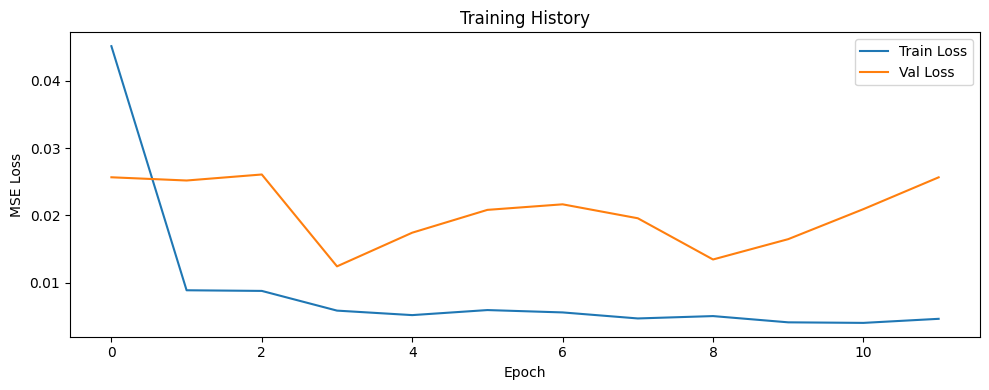

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [ ]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predictions shape: (370, 1)
Actuals shape     : (370, 1)


---
# 7. Visualisation

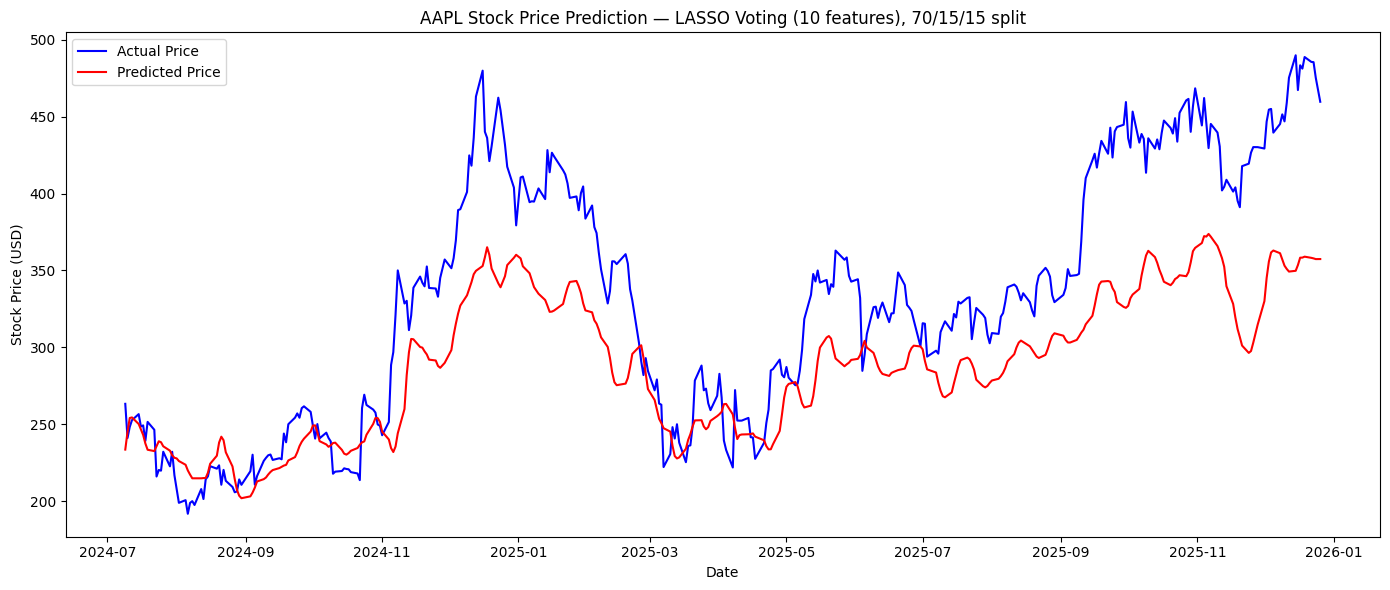

In [ ]:
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price',    color='blue')
plt.plot(test_dates, prediction.flatten(),    label='Predicted Price', color='red')
plt.title(f'AAPL Stock Price Prediction \u2014 LASSO Voting '
          f'({len(feature_cols)} features), 70/15/15 split')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


---
# 8. Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with LASSO Voting Features ({len(feature_cols)}) - 70/15/15 split')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with LASSO Voting Features (10) - 70/15/15 split
Features: ['Close', 'High', 'Low', 'Volume', 'MACD_hist', 'OBV', 'days_since_start', 'aaa_rate', 'unemployment_change_3m', 'sentiment_momentum']
  MSE  : 3417.6874
  RMSE : 58.4610
  MAE  : 46.4166
  MAPE : 12.54%


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


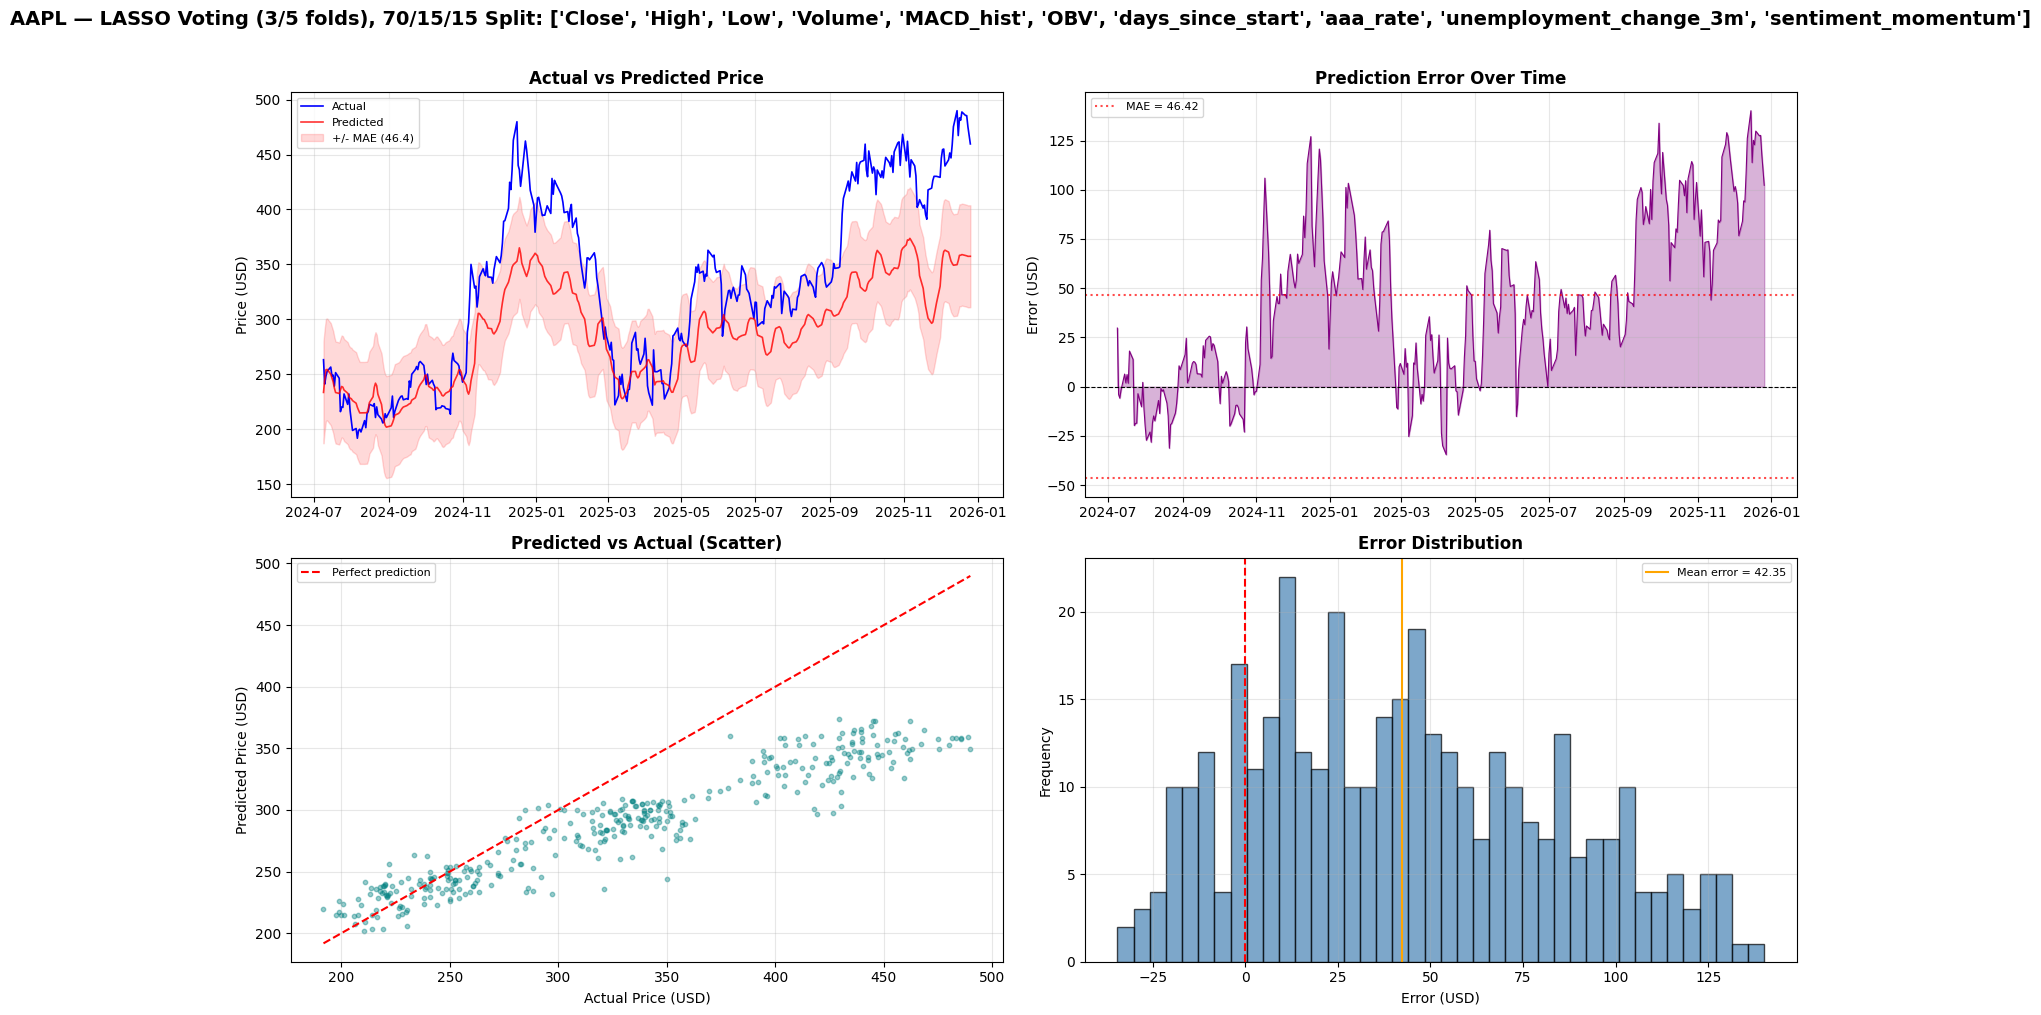

Mean Error: 42.3469  |  Std Error: 40.3042
Max Over-prediction: 140.1323  |  Max Under-prediction: -34.5176
Mean Abs % Error: 12.54%


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'AAPL — LASSO Voting (3/5 folds), 70/15/15 Split: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')